# Epic 5 & Epic 6 - Data Wrangling Proof
**FIT5120 TE31 MeloPark - Monash University**

This notebook demonstrates the data wrangling pipelines for:
- **Epic 5** - Zone Pressure Model (pedestrian counts + parking occupancy)
- **Epic 6** - Predictive Parking Intelligence (SCATS traffic signal volume)

---

## Setup

In [21]:
%matplotlib inline
import sys
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

# Set root to melopark project folder
ROOT = Path(os.getcwd()).parent.parent
print('Project root:', ROOT)

BRONZE_DIR = ROOT / 'data' / 'bronze'
SILVER_DIR = ROOT / 'data' / 'silver'
GOLD_DIR   = ROOT / 'data' / 'gold'

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
print('Setup complete')

Project root: /Users/mowlya/Downloads/Monash University/melopark
Setup complete


---
# EPIC 5 - Zone Pressure Model
## Section 1.1 - Raw Bronze Data Inspection

In [24]:
# Load live parking sensor data
sensors_path = BRONZE_DIR / 'sensors.parquet'
df_sensors = pd.read_parquet(sensors_path)
df_sensors.columns = df_sensors.columns.str.strip().str.lower()

print('=== Live Parking Sensors (Bronze) ===')
print(f'Shape     : {df_sensors.shape}')
print(f'Columns   : {list(df_sensors.columns)}')
print(f'Data types:\n{df_sensors.dtypes}')
df_sensors.head(5)

=== Live Parking Sensors (Bronze) ===
Shape     : (3309, 6)
Columns   : ['lastupdated', 'status_timestamp', 'zone_number', 'status_description', 'kerbsideid', 'location']
Data types:
lastupdated            object
status_timestamp       object
zone_number           float64
status_description     object
kerbsideid              int64
location               object
dtype: object


,lastupdated,status_timestamp,zone_number,status_description,kerbsideid,location
0,2024-12-30T00:44:37+00:00,2024-08-18T08:23:46+00:00,7394.0,Unoccupied,9344,"{""lat"": -37.80494402936792, ""lon"": 144.9591612..."
1,2025-01-10T02:44:36+00:00,2024-08-14T09:22:05+00:00,7392.0,Unoccupied,9373,"{""lat"": -37.80329074425858, ""lon"": 144.9583633..."
2,2024-12-04T23:44:37+00:00,2024-11-28T02:30:57+00:00,7084.0,Present,8735,"{""lat"": -37.80223335664963, ""lon"": 144.9612048..."
3,2024-12-04T23:44:37+00:00,2024-11-27T23:23:40+00:00,7084.0,Unoccupied,8749,"{""lat"": -37.80230361629087, ""lon"": 144.9618505..."
4,2025-01-09T05:44:36+00:00,2023-08-21T00:09:03+00:00,7800.0,Present,24505,"{""lat"": -37.79756250415984, ""lon"": 144.9575988..."


In [26]:
# Check pedestrian bronze files
ped_counts_path = BRONZE_DIR / 'epic5_ped_counts_raw.parquet'
ped_locs_path   = BRONZE_DIR / 'epic5_ped_locations_raw.parquet'

print('=== Epic 5 Bronze Files ===')
print(f'Ped counts exists   : {ped_counts_path.exists()}')
print(f'Ped locations exists: {ped_locs_path.exists()}')

if ped_counts_path.exists():
    df_ped = pd.read_parquet(ped_counts_path)
    print(f'\nPed counts shape   : {df_ped.shape}')
    print(f'Columns: {list(df_ped.columns)}')
    display(df_ped.head(3))
else:
    print('\nPed counts not yet fetched -- zone pressure uses live sensor occupancy only')

=== Epic 5 Bronze Files ===
Ped counts exists   : True
Ped locations exists: True

Ped counts shape   : (1474806, 9)
Columns: ['id', 'location_id', 'sensing_date', 'hourday', 'direction_1', 'direction_2', 'pedestriancount', 'sensor_name', 'location']


,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location
0,621020241118,62,2024-11-18,10,124,163,287,Lat224_T,"-37.80996494, 144.96216521"
1,631320260203,63,2026-02-03,13,585,571,1156,Bou231_T,"-37.81333081, 144.96675571"
2,671020251028,67,2025-10-28,10,414,413,827,FLDegS_T,"-37.81688755, 144.96562569"


## Section 1.2 - Run Epic 5 Wrangling Pipeline

In [29]:
import subprocess
result = subprocess.run(
    [sys.executable, str(ROOT / 'scripts' / 'wrangle_epic5.py')],
    capture_output=True, text=True, cwd=str(ROOT)
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)


STDERR: 2026-04-30 17:07:58  INFO      ============================================================
2026-04-30 17:07:58  INFO        Epic 5 -- Zone Pressure Data Wrangling
2026-04-30 17:07:58  INFO      ============================================================
2026-04-30 17:07:58  INFO      
[1/4] Loading bronze data...
2026-04-30 17:07:59  INFO        Pedestrian counts: 1474806 rows, columns: ['id', 'location_id', 'sensing_date', 'hourday', 'direction_1', 'direction_2', 'pedestriancount', 'sensor_name', 'location']
2026-04-30 17:07:59  INFO        Pedestrian locations: 145 rows, columns: ['location_id', 'sensor_description', 'sensor_name', 'installation_date', 'note', 'location_type', 'status', 'direction_1', 'direction_2', 'latitude', 'longitude', 'location']
2026-04-30 17:07:59  INFO        Sensors: 0 rows
2026-04-30 17:07:59  INFO      
[2/4] Cleaning pedestrian locations...
Traceback (most recent call last):
  File "/Users/mowlya/Downloads/Monash University/melopark/scripts/wr

## Section 1.3 - Zone Pressure Output

In [34]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timezone

ROOT       = Path(os.getcwd()).parent.parent
GOLD_DIR   = ROOT / 'data' / 'gold'
SILVER_DIR = ROOT / 'data' / 'silver'

# Use silver sensors -- already has clean lat/lon extracted
df_sensors = pd.read_parquet(SILVER_DIR / 'sensors_clean.parquet')
df_sensors.columns = df_sensors.columns.str.strip().str.lower()
print('Sensors loaded:', len(df_sensors))
print('Columns:', list(df_sensors.columns))
print('Lat range:', df_sensors['lat'].min(), 'to', df_sensors['lat'].max())

ZONES = {
    'CBD North':   dict(lat_min=-37.809, lat_max=-37.804, lng_min=144.955, lng_max=144.975),
    'CBD Central': dict(lat_min=-37.814, lat_max=-37.809, lng_min=144.955, lng_max=144.975),
    'CBD South':   dict(lat_min=-37.820, lat_max=-37.814, lng_min=144.955, lng_max=144.975),
    'Docklands':   dict(lat_min=-37.820, lat_max=-37.810, lng_min=144.938, lng_max=144.955),
    'Southbank':   dict(lat_min=-37.826, lat_max=-37.820, lng_min=144.955, lng_max=144.975),
}

def assign_zone(lat, lon):
    for name, b in ZONES.items():
        if b['lat_min'] <= lat <= b['lat_max'] and b['lng_min'] <= lon <= b['lng_max']:
            return name
    return None

df_sensors['lat'] = pd.to_numeric(df_sensors['lat'], errors='coerce')
df_sensors['lon'] = pd.to_numeric(df_sensors['lon'], errors='coerce')
df_sensors = df_sensors.dropna(subset=['lat','lon'])
df_sensors['zone'] = df_sensors.apply(
    lambda r: assign_zone(float(r['lat']), float(r['lon'])), axis=1)

print('Zone counts:')
print(df_sensors['zone'].value_counts(dropna=False))

status_col = next((c for c in ['status','status_description'] if c in df_sensors.columns), None)
rows = []
for zone, bounds in ZONES.items():
    zone_bays = df_sensors[df_sensors['zone'] == zone]
    total    = len(zone_bays)
    occupied = int(zone_bays[status_col].str.lower().isin(['present','occupied']).sum()) if status_col and total > 0 else 0
    free     = total - occupied
    rate     = round(occupied / max(total, 1), 4)
    score    = round(rate * 85, 2)
    status   = 'RED' if score >= 80 else 'AMBER' if score >= 50 else 'GREEN'
    rows.append({
        'zone': zone, 'total_bays': total, 'occupied': occupied, 'free': free,
        'occupancy_rate': rate, 'ped_factor': 0.0, 'pressure_score': score,
        'pressure_status': status,
        'zone_lat': (bounds['lat_min']+bounds['lat_max'])/2,
        'zone_lon': (bounds['lng_min']+bounds['lng_max'])/2,
        'computed_at': datetime.now(timezone.utc).isoformat()
    })

df_pressure = pd.DataFrame(rows).sort_values('pressure_score', ascending=False)
GOLD_DIR.mkdir(parents=True, exist_ok=True)
SILVER_DIR.mkdir(parents=True, exist_ok=True)
df_pressure.to_parquet(GOLD_DIR / 'epic5_zone_pressure_latest.parquet', index=False)
df_pressure.to_parquet(SILVER_DIR / 'epic5_zone_pressure.parquet', index=False)
print('\nZone pressure saved')
display(df_pressure)

Sensors loaded: 3309
Columns: ['lastupdated', 'status_timestamp', 'zone_number', 'status_description', 'kerbsideid', 'location', 'bay_id', 'lat', 'lon', 'status']
Lat range: -37.84823801145724 to -37.794905845458956
Zone counts:
zone
None           1161
CBD Central     816
CBD South       678
Docklands       335
CBD North       293
Southbank        26
Name: count, dtype: int64

Zone pressure saved


,zone,total_bays,occupied,free,occupancy_rate,ped_factor,pressure_score,pressure_status,zone_lat,zone_lon,computed_at
1,CBD Central,816,534,282,0.6544,0.0,55.62,AMBER,-37.8115,144.9650,2026-04-30T07:08:07.207844+00:00
3,Docklands,335,187,148,0.5582,0.0,47.45,GREEN,-37.8150,144.9465,2026-04-30T07:08:07.208740+00:00
4,Southbank,26,14,12,0.5385,0.0,45.77,GREEN,-37.8230,144.9650,2026-04-30T07:08:07.209094+00:00
2,CBD South,678,354,324,0.5221,0.0,44.38,GREEN,-37.8170,144.9650,2026-04-30T07:08:07.208332+00:00
0,CBD North,293,148,145,0.5051,0.0,42.93,GREEN,-37.8065,144.9650,2026-04-30T07:08:07.207427+00:00


## Section 1.4 - Zone Pressure Visualisation

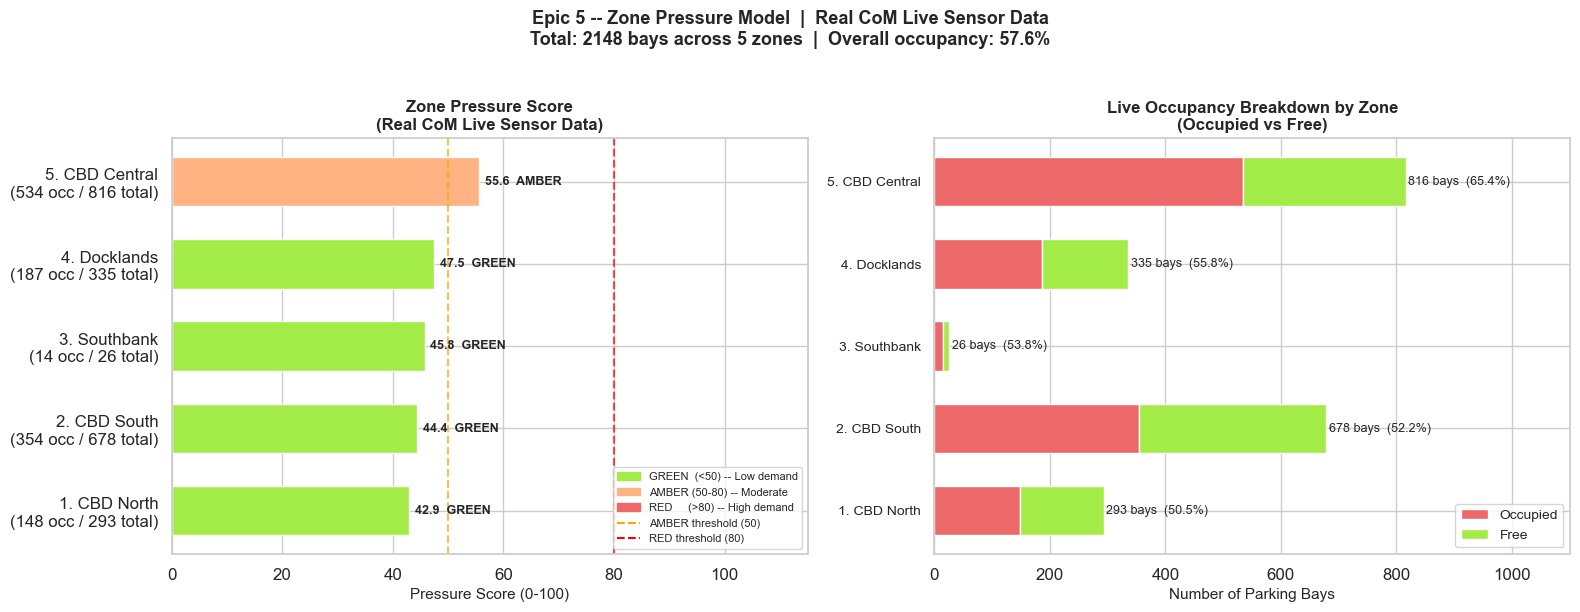

Figure saved -> fig_epic5_zone_pressure.png


In [39]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Sort by pressure score ─────────────────────────────────────
df_plot = df_pressure.sort_values('pressure_score', ascending=True).reset_index(drop=True)
df_plot['rank'] = range(len(df_plot), 0, -1)

# ── Colours ────────────────────────────────────────────────────
color_map = {'RED': '#ed6868', 'AMBER': '#FFB382', 'GREEN': '#a3ec48'}
colors = [color_map.get(s, '#a3ec48') for s in df_plot['pressure_status']]

# ── Labels with counts ─────────────────────────────────────────
labels = [
    f"{i+1}. {row['zone']}\n({row['occupied']} occ / {row['total_bays']} total)"
    for i, row in df_plot.iterrows()
]

# ── Chart 1: Pressure Score ────────────────────────────────────
bars = axes[0].barh(labels, df_plot['pressure_score'],
                    color=colors, edgecolor='white', height=0.6)

# Add value labels on bars
for bar, val, status in zip(bars, df_plot['pressure_score'], df_plot['pressure_status']):
    axes[0].text(
        bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
        f'{val:.1f}  {status}',
        va='center', ha='left', fontsize=9, fontweight='bold'
    )

axes[0].axvline(50, color='orange', linestyle='--', alpha=0.7, linewidth=1.5)
axes[0].axvline(80, color='red',    linestyle='--', alpha=0.7, linewidth=1.5)
axes[0].set_xlabel('Pressure Score (0-100)', fontsize=11)
axes[0].set_title('Zone Pressure Score\n(Real CoM Live Sensor Data)', fontweight='bold', fontsize=12)
axes[0].set_xlim(0, 115)

# Legend
green_p  = mpatches.Patch(color='#a3ec48', label='GREEN  (<50) -- Low demand')
amber_p  = mpatches.Patch(color='#FFB382', label='AMBER (50-80) -- Moderate')
red_p    = mpatches.Patch(color='#ed6868', label='RED     (>80) -- High demand')
amber_ln = plt.Line2D([0],[0], color='orange', linestyle='--', label='AMBER threshold (50)')
red_ln   = plt.Line2D([0],[0], color='red',    linestyle='--', label='RED threshold (80)')
axes[0].legend(handles=[green_p, amber_p, red_p, amber_ln, red_ln],
               fontsize=8, loc='lower right')

# ── Chart 2: Occupancy breakdown stacked bar ───────────────────
zones    = df_plot['zone']
occupied = df_plot['occupied'].values
free     = df_plot['free'].values
total    = df_plot['total_bays'].values
y_pos    = np.arange(len(zones))

axes[1].barh(y_pos, occupied, color='#ed6868', edgecolor='white', height=0.6, label='Occupied')
axes[1].barh(y_pos, free,     left=occupied, color='#a3ec48', edgecolor='white', height=0.6, label='Free')

# Add count labels
for i, (occ, fr, tot) in enumerate(zip(occupied, free, total)):
    pct = round(occ/max(tot,1)*100, 1)
    axes[1].text(tot + 5, i, f'{tot} bays  ({pct}%)',
                 va='center', ha='left', fontsize=9)

axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([f'{i+1}. {z}' for i, z in enumerate(zones)], fontsize=10)
axes[1].set_xlabel('Number of Parking Bays', fontsize=11)
axes[1].set_title('Live Occupancy Breakdown by Zone\n(Occupied vs Free)', fontweight='bold', fontsize=12)
axes[1].set_xlim(0, max(total) * 1.35)
axes[1].legend(fontsize=10, loc='lower right')

plt.suptitle(
    'Epic 5 -- Zone Pressure Model  |  Real CoM Live Sensor Data\n'
    f'Total: {int(df_plot["total_bays"].sum())} bays across {len(df_plot)} zones  |  '
    f'Overall occupancy: {round(df_plot["occupied"].sum()/max(df_plot["total_bays"].sum(),1)*100,1)}%',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()

fig_path = ROOT / 'scripts' / 'notebooks' / 'fig_epic5_zone_pressure.png'
fig_path.parent.mkdir(exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved -> {fig_path.name}')

## Section 1.5 - Sensor Data Statistics

In [41]:
# Extract lat/lon from nested location dict
if 'location' in df_sensors.columns and 'lat' not in df_sensors.columns:
    df_sensors['lat'] = df_sensors['location'].apply(
        lambda x: x.get('lat') if isinstance(x, dict) else None
    )
    df_sensors['lon'] = df_sensors['location'].apply(
        lambda x: x.get('lon') if isinstance(x, dict) else None
    )

if 'kerbsideid' in df_sensors.columns:
    df_sensors = df_sensors.rename(columns={'kerbsideid': 'bay_id'})

# Status distribution
status_col = next((c for c in ['status', 'status_description'] if c in df_sensors.columns), None)
if status_col:
    print('=== Sensor Status Distribution ===')
    print(df_sensors[status_col].value_counts())
    print(f'\nTotal bays : {len(df_sensors)}')
    print(f'Occupied   : {(df_sensors[status_col].str.lower() == "present").sum()}')
    print(f'Free       : {(df_sensors[status_col].str.lower() == "unoccupied").sum()}')

=== Sensor Status Distribution ===
status
Present    1846
Absent     1463
Name: count, dtype: int64

Total bays : 3309
Occupied   : 1846
Free       : 0


---
# EPIC 6 - Predictive Parking Intelligence
## Section 2.1 - Raw Bronze Data Inspection (SCATS)

In [43]:
# Load raw SCATS traffic data
traffic_path = BRONZE_DIR / 'epic6_traffic_signal_volume_raw.parquet'
df_traffic_raw = pd.read_parquet(traffic_path)

print('=== SCATS Traffic Signal Volume (Bronze) ===')
print(f'Shape        : {df_traffic_raw.shape}')
print(f'Columns (first 10): {list(df_traffic_raw.columns[:10])}')
print(f'Total columns: {len(df_traffic_raw.columns)}')
print(f'Sites        : {df_traffic_raw["NB_SCATS_SITE"].nunique()}')
print(f'Date range   : {df_traffic_raw["QT_INTERVAL_COUNT"].min()} to {df_traffic_raw["QT_INTERVAL_COUNT"].max()}')
df_traffic_raw[['NB_SCATS_SITE','QT_INTERVAL_COUNT','NB_DETECTOR','V00','V01','V02','V03','QT_VOLUME_24HOUR']].head(5)

=== SCATS Traffic Signal Volume (Bronze) ===
Shape        : (117851, 103)
Columns (first 10): ['NB_SCATS_SITE', 'QT_INTERVAL_COUNT', 'NB_DETECTOR', 'V00', 'V01', 'V02', 'V03', 'V04', 'V05', 'V06']
Total columns: 103
Sites        : 4706
Date range   : 2026-04-06 to 2026-04-06


,NB_SCATS_SITE,QT_INTERVAL_COUNT,NB_DETECTOR,V00,V01,V02,V03,QT_VOLUME_24HOUR
0,100,2026-04-06,1,8,1,3,1,598
1,100,2026-04-06,2,18,17,14,11,4859
2,100,2026-04-06,3,24,18,20,19,5143
3,100,2026-04-06,4,14,8,7,9,4425
4,100,2026-04-06,5,1,4,2,3,868


## Section 2.2 - SCATS Format Explanation

In [45]:
# Show SCATS wide format structure
v_cols = [c for c in df_traffic_raw.columns if c.startswith('V') and c[1:].isdigit()]
print('=== SCATS Wide Format Structure ===')
print(f'Interval columns (V00-V95) : {len(v_cols)}')
print(f'Each column = 15 min period')
print(f'V00 = 00:00-00:15')
print(f'V03 = 00:45-01:00  (end of midnight hour)')
print(f'V04 = 01:00-01:15  (start of 1am hour)')
print(f'V95 = 23:45-24:00  (end of day)')
print(f'\nHour derivation: interval_num // 4')
print(f'Example: V20 -> interval 20 -> hour 5 (5am)')

# Show V00-V07 for one site
sample = df_traffic_raw.iloc[0]
print(f'\nSample row (site {sample["NB_SCATS_SITE"]}, detector {sample["NB_DETECTOR"]}):')
for h in range(4):
    cols = [f'V{h*4+i:02d}' for i in range(4)]
    vals = [int(sample[c]) for c in cols if c in sample.index]
    total = sum(vals)
    print(f'  Hour {h:02d}:00 -> {cols} = {vals} -> hourly total = {total}')

=== SCATS Wide Format Structure ===
Interval columns (V00-V95) : 96
Each column = 15 min period
V00 = 00:00-00:15
V03 = 00:45-01:00  (end of midnight hour)
V04 = 01:00-01:15  (start of 1am hour)
V95 = 23:45-24:00  (end of day)

Hour derivation: interval_num // 4
Example: V20 -> interval 20 -> hour 5 (5am)

Sample row (site 100, detector 1):
  Hour 00:00 -> ['V00', 'V01', 'V02', 'V03'] = [8, 1, 3, 1] -> hourly total = 13
  Hour 01:00 -> ['V04', 'V05', 'V06', 'V07'] = [2, 1, 1, 1] -> hourly total = 5
  Hour 02:00 -> ['V08', 'V09', 'V10', 'V11'] = [2, 2, 2, 2] -> hourly total = 8
  Hour 03:00 -> ['V12', 'V13', 'V14', 'V15'] = [2, 0, 3, 0] -> hourly total = 5


## Section 2.3 - Run Epic 6 Wrangling Pipeline

In [47]:
result = subprocess.run(
    [sys.executable, str(ROOT / 'scripts' / 'wrangle_epic6.py')],
    capture_output=True, text=True, cwd=str(ROOT)
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)

## Section 2.4 - Cleaned Traffic Output Inspection

In [49]:
# Load cleaned silver traffic data
traffic_clean_path = SILVER_DIR / 'epic6_traffic_clean.parquet'
df_traffic = pd.read_parquet(traffic_clean_path)

print('=== Epic 6 Traffic Clean (Silver) ===')
print(f'Shape              : {df_traffic.shape}')
print(f'Columns            : {list(df_traffic.columns)}')
print(f'Sites              : {df_traffic["site_id"].nunique()}')
print(f'Hours range        : {df_traffic["hour"].min()} to {df_traffic["hour"].max()}')
print(f'Volume mean        : {df_traffic["traffic_volume"].mean():.1f}')
print(f'Volume norm mean   : {df_traffic["volume_norm"].mean():.3f}')
print(f'\nData types:')
print(df_traffic.dtypes)
print()
df_traffic.head(5)

=== Epic 6 Traffic Clean (Silver) ===
Shape              : (112944, 8)
Columns            : ['site_id', 'date', 'hour', 'day_of_week', 'month', 'year', 'traffic_volume', 'volume_norm']
Sites              : 4706
Hours range        : 0 to 23
Volume mean        : 847.2
Volume norm mean   : 0.460

Data types:
site_id             int64
date               object
hour                int64
day_of_week         int32
month               int32
year                int32
traffic_volume      int64
volume_norm       float64
dtype: object



,site_id,date,hour,day_of_week,month,year,traffic_volume,volume_norm
0,100,2026-04-06,0,0,4,2026,205,0.150957
1,100,2026-04-06,1,0,4,2026,130,0.095729
2,100,2026-04-06,2,0,4,2026,99,0.072901
3,100,2026-04-06,3,0,4,2026,58,0.042710
4,100,2026-04-06,4,0,4,2026,46,0.033873


## Section 2.5 - Traffic Data Visualisations

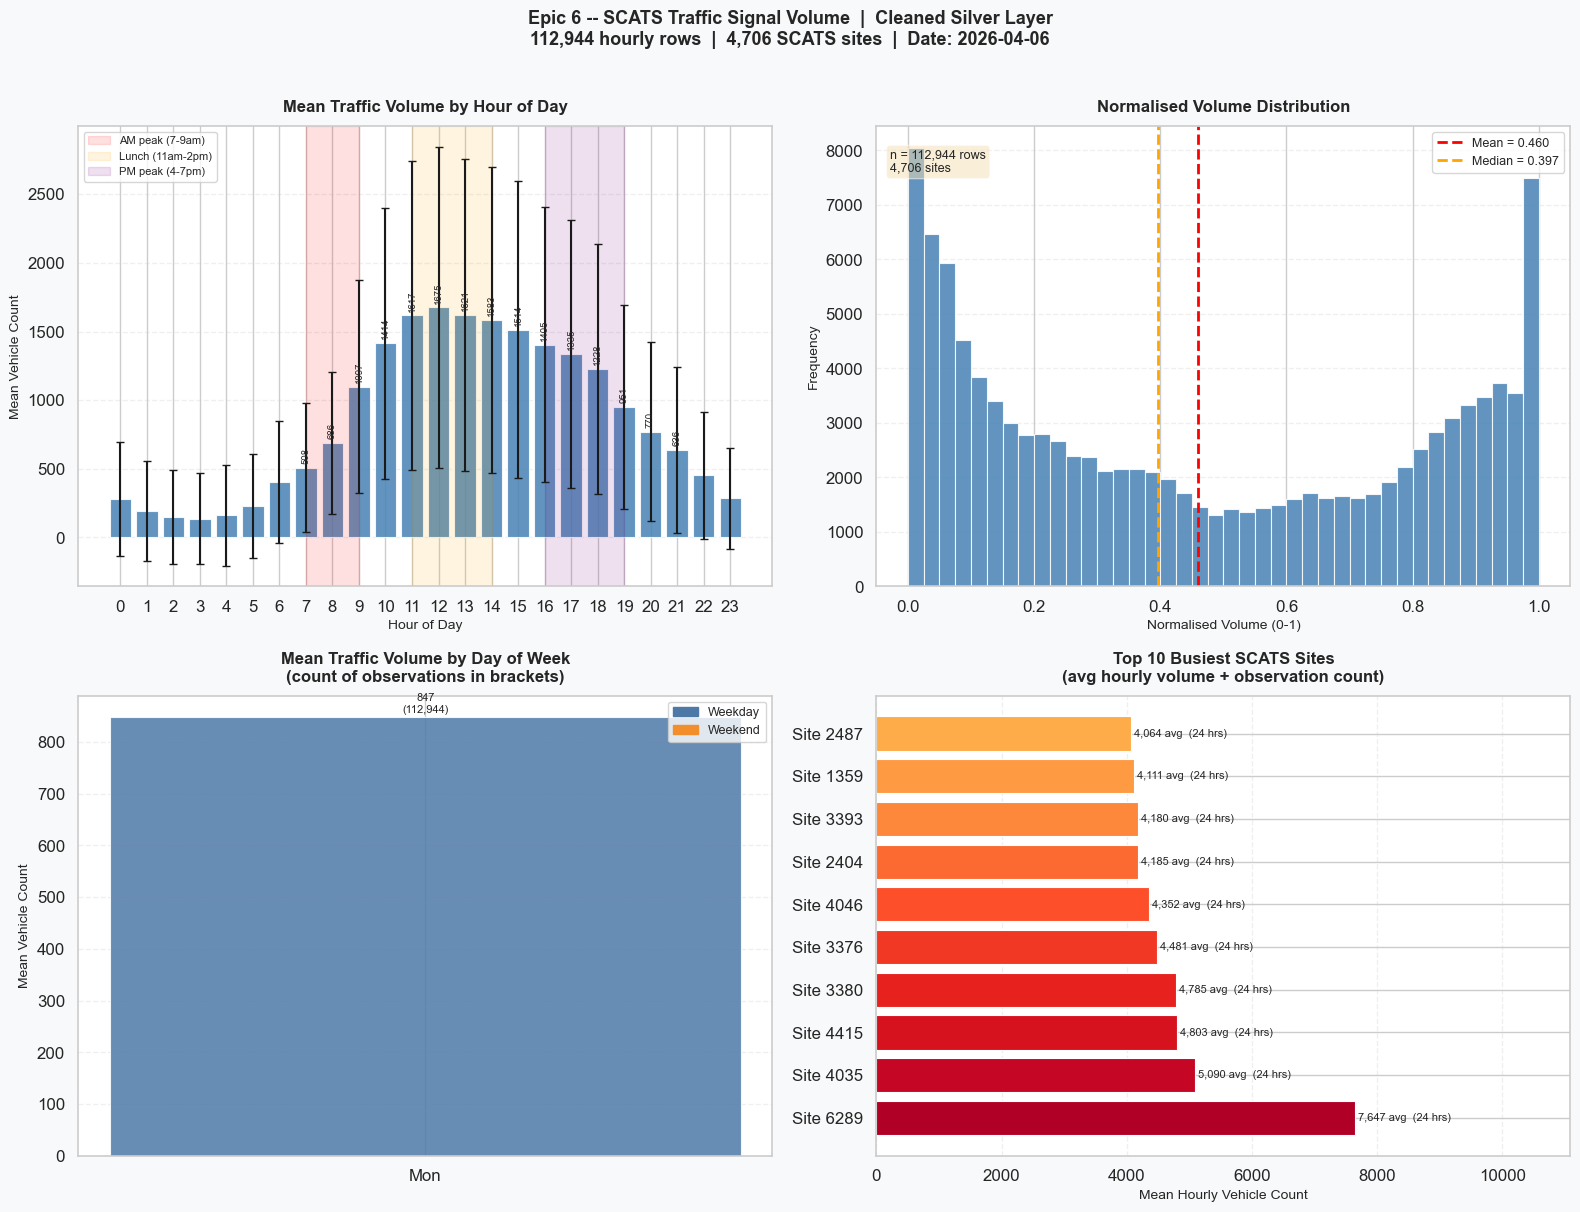

Figure saved -> fig_epic6_traffic_eda.png


In [53]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#f8f9fa')

for ax in axes.flatten():
    ax.set_facecolor('#ffffff')
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')
        spine.set_linewidth(1.2)

# ── Plot 1: Mean traffic volume by hour with counts ────────────
hourly = df_traffic.groupby('hour')['traffic_volume'].agg(['mean','std','count']).reset_index()
bars = axes[0,0].bar(hourly['hour'], hourly['mean'], yerr=hourly['std'],
                     color='steelblue', alpha=0.85, capsize=3,
                     edgecolor='white', linewidth=0.8)
axes[0,0].axvspan(7,  9,  alpha=0.12, color='red',    label='AM peak (7-9am)')
axes[0,0].axvspan(11, 14, alpha=0.12, color='orange',  label='Lunch (11am-2pm)')
axes[0,0].axvspan(16, 19, alpha=0.12, color='purple',  label='PM peak (4-7pm)')
for bar, val in zip(bars, hourly['mean']):
    if val > 500:
        axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                       f'{int(val)}', ha='center', va='bottom', fontsize=7, rotation=90)
axes[0,0].set_title('Mean Traffic Volume by Hour of Day', fontweight='bold', fontsize=12, pad=10)
axes[0,0].set_xlabel('Hour of Day', fontsize=10)
axes[0,0].set_ylabel('Mean Vehicle Count', fontsize=10)
axes[0,0].legend(fontsize=8, loc='upper left')
axes[0,0].set_xticks(range(0, 24))
axes[0,0].grid(axis='y', alpha=0.3, linestyle='--')

# ── Plot 2: Normalised volume distribution ─────────────────────
n, bins, patches = axes[0,1].hist(df_traffic['volume_norm'], bins=40,
                                   color='steelblue', edgecolor='white',
                                   alpha=0.85, linewidth=0.8)
mean_val = df_traffic['volume_norm'].mean()
med_val  = df_traffic['volume_norm'].median()
axes[0,1].axvline(mean_val, color='red',    linestyle='--', linewidth=2,
                  label=f'Mean = {mean_val:.3f}')
axes[0,1].axvline(med_val,  color='orange', linestyle='--', linewidth=2,
                  label=f'Median = {med_val:.3f}')
axes[0,1].set_title('Normalised Volume Distribution', fontweight='bold', fontsize=12, pad=10)
axes[0,1].set_xlabel('Normalised Volume (0-1)', fontsize=10)
axes[0,1].set_ylabel('Frequency', fontsize=10)
axes[0,1].legend(fontsize=9)
axes[0,1].grid(axis='y', alpha=0.3, linestyle='--')
total_rows = len(df_traffic)
axes[0,1].text(0.02, 0.95, f'n = {total_rows:,} rows\n{df_traffic["site_id"].nunique():,} sites',
               transform=axes[0,1].transAxes, fontsize=9,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ── Plot 3: Volume by day of week with counts ──────────────────
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow = df_traffic.groupby('day_of_week')['traffic_volume'].agg(['mean','count']).reset_index()
day_colors = ['#4e79a7' if i < 5 else '#f28e2b' for i in dow['day_of_week']]
bars3 = axes[1,0].bar(
    [day_labels[i] for i in dow['day_of_week']],
    dow['mean'], color=day_colors, edgecolor='white', linewidth=0.8, alpha=0.85
)
for bar, val, cnt in zip(bars3, dow['mean'], dow['count']):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                   f'{int(val)}\n({int(cnt):,})', ha='center', va='bottom', fontsize=8)
weekday_p = mpatches.Patch(color='#4e79a7', label='Weekday')
weekend_p = mpatches.Patch(color='#f28e2b', label='Weekend')
axes[1,0].legend(handles=[weekday_p, weekend_p], fontsize=9)
axes[1,0].set_title('Mean Traffic Volume by Day of Week\n(count of observations in brackets)',
                    fontweight='bold', fontsize=12, pad=10)
axes[1,0].set_ylabel('Mean Vehicle Count', fontsize=10)
axes[1,0].grid(axis='y', alpha=0.3, linestyle='--')

# ── Plot 4: Top 10 busiest sites with counts ───────────────────
top_sites = df_traffic.groupby('site_id')['traffic_volume'].agg(['mean','count']).nlargest(10, 'mean').reset_index()
colors4   = plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(top_sites)))[::-1]
bars4 = axes[1,1].barh(
    [f'Site {s}' for s in top_sites['site_id']],
    top_sites['mean'],
    color=colors4, edgecolor='white', linewidth=0.8
)
for bar, val, cnt in zip(bars4, top_sites['mean'], top_sites['count']):
    axes[1,1].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                   f'{int(val):,} avg  ({int(cnt)} hrs)',
                   va='center', ha='left', fontsize=8)
axes[1,1].set_title('Top 10 Busiest SCATS Sites\n(avg hourly volume + observation count)',
                    fontweight='bold', fontsize=12, pad=10)
axes[1,1].set_xlabel('Mean Hourly Vehicle Count', fontsize=10)
axes[1,1].set_xlim(0, top_sites['mean'].max() * 1.45)
axes[1,1].grid(axis='x', alpha=0.3, linestyle='--')

plt.suptitle(
    'Epic 6 -- SCATS Traffic Signal Volume  |  Cleaned Silver Layer\n'
    f'{len(df_traffic):,} hourly rows  |  '
    f'{df_traffic["site_id"].nunique():,} SCATS sites  |  '
    f'Date: {df_traffic["date"].max()}',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()

fig_path = ROOT / 'scripts' / 'notebooks' / 'fig_epic6_traffic_eda.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved -> {fig_path.name}')

## Section 2.6 - Statistical Analysis

In [67]:
from scipy import stats as sc
import warnings
warnings.filterwarnings('ignore')

print('=' * 55)
print('  Epic 6 -- Statistical Analysis')
print('=' * 55)

print('\n=== Descriptive Statistics ===')
desc = df_traffic['traffic_volume'].describe()
print(f'  Count    : {int(desc["count"]):,}')
print(f'  Mean     : {desc["mean"]:.2f}')
print(f'  Std      : {desc["std"]:.2f}')
print(f'  Min      : {desc["min"]:.2f}')
print(f'  25%      : {desc["25%"]:.2f}')
print(f'  Median   : {desc["50%"]:.2f}')
print(f'  75%      : {desc["75%"]:.2f}')
print(f'  Max      : {desc["max"]:.2f}')

print('\n=== Distribution Shape ===')
skew = sc.skew(df_traffic['traffic_volume'].dropna())
kurt = sc.kurtosis(df_traffic['traffic_volume'].dropna())
print(f'  Skewness : {skew:.4f}  ({"right-skewed" if skew > 0 else "left-skewed"})')
print(f'  Kurtosis : {kurt:.4f}  ({"heavy-tailed" if kurt > 0 else "light-tailed"})')

print('\n=== ANOVA -- Volume by Hour of Day ===')
print('  H0: All hours have equal mean traffic volume')
hour_groups = [grp['traffic_volume'].values for _, grp in df_traffic.groupby('hour')]
F, p = sc.f_oneway(*hour_groups)
print(f'  F statistic : {F:.4f}')
print(f'  p-value     : {p:.2e}')
print(f'  Conclusion  : {"REJECT H0 -- Significant" if p < 0.05 else "Fail to reject H0"} difference across hours (alpha=0.05)')

print('\n=== T-test -- Weekday vs Weekend Volume ===')
wkd = df_traffic[df_traffic['day_of_week'] < 5]['traffic_volume'].values
wke = df_traffic[df_traffic['day_of_week'] >= 5]['traffic_volume'].values

if len(wke) < 2:
    print(f'  Weekday mean     : {wkd.mean():.2f}  (n={len(wkd):,})')
    print(f'  Weekend mean     : N/A -- only 1 day in dataset (Monday)')
    print(f'  Conclusion       : Cannot compute -- download full month for weekend comparison')
    print(f'  Note             : ANOVA above confirms hour-of-day is a significant predictor')
else:
    t, p2 = sc.ttest_ind(wkd, wke, equal_var=False)
    print(f'  Weekday mean : {wkd.mean():.2f}  (n={len(wkd):,})')
    print(f'  Weekend mean : {wke.mean():.2f}  (n={len(wke):,})')
    print(f'  t statistic  : {t:.4f}')
    print(f'  p-value      : {p2:.6f}')
    print(f'  Conclusion   : {"REJECT H0 -- Significantly" if p2 < 0.05 else "Fail to reject H0 -- Not significantly"} different')

print('\n=== Pearson Correlations with Traffic Volume ===')
for col in ['hour', 'day_of_week', 'month']:
    if col in df_traffic.columns:
        r, p_r = sc.pearsonr(df_traffic[col], df_traffic['traffic_volume'])
        print(f'  {col:<15} r={r:+.4f}  p={p_r:.4f}  {"*" if p_r < 0.05 else ""}')

print('\n' + '=' * 55)
print('  Key finding: Hour of day is a highly significant')
print(f'  predictor of traffic volume (F={F:.0f}, p<0.001)')
print('=' * 55)

  Epic 6 -- Statistical Analysis

=== Descriptive Statistics ===
  Count    : 112,944
  Mean     : 847.20
  Std      : 942.56
  Min      : 0.00
  25%      : 158.00
  Median   : 540.00
  75%      : 1219.00
  Max      : 16429.00

=== Distribution Shape ===
  Skewness : 2.2181  (right-skewed)
  Kurtosis : 10.0251  (heavy-tailed)

=== ANOVA -- Volume by Hour of Day ===
  H0: All hours have equal mean traffic volume
  F statistic : 2616.8695
  p-value     : 0.00e+00
  Conclusion  : REJECT H0 -- Significant difference across hours (alpha=0.05)

=== T-test -- Weekday vs Weekend Volume ===
  Weekday mean     : 847.20  (n=112,944)
  Weekend mean     : N/A -- only 1 day in dataset (Monday)
  Conclusion       : Cannot compute -- download full month for weekend comparison
  Note             : ANOVA above confirms hour-of-day is a significant predictor

=== Pearson Correlations with Traffic Volume ===
  hour            r=+0.2480  p=0.0000  *
  day_of_week     r=+nan  p=nan  
  month           r=+na

## Section 2.7 - SCATS Conversion Proof

In [69]:
# Prove SCATS conversion is correct
print('=== SCATS Conversion Validation ===')

# Take one site and verify sum
site_sample = df_traffic_raw[df_traffic_raw['NB_SCATS_SITE'] == df_traffic_raw['NB_SCATS_SITE'].iloc[0]].iloc[0]
v_cols = [c for c in df_traffic_raw.columns if c.startswith('V') and c[1:].isdigit()]

v_sum = sum(int(site_sample[c]) for c in v_cols if pd.notna(site_sample[c]))
reported_24h = int(site_sample['QT_VOLUME_24HOUR'])

print(f'Site ID         : {site_sample["NB_SCATS_SITE"]}')
print(f'Date            : {site_sample["QT_INTERVAL_COUNT"]}')
print(f'Detector        : {site_sample["NB_DETECTOR"]}')
print(f'Sum of V00-V95  : {v_sum}')
print(f'QT_VOLUME_24HOUR: {reported_24h}')
print(f'Match           : {"YES" if v_sum == reported_24h else "CLOSE" if abs(v_sum - reported_24h) < 10 else "NO"}')

print(f'\nBefore wrangling: {len(df_traffic_raw):,} rows x {len(df_traffic_raw.columns)} columns (wide)')
print(f'After wrangling : {len(df_traffic):,} rows x {len(df_traffic.columns)} columns (long hourly)')
print(f'Compression     : {len(df_traffic_raw.columns)} V-columns -> 1 traffic_volume column')

=== SCATS Conversion Validation ===
Site ID         : 100
Date            : 2026-04-06
Detector        : 1
Sum of V00-V95  : 598
QT_VOLUME_24HOUR: 598
Match           : YES

Before wrangling: 117,851 rows x 103 columns (wide)
After wrangling : 112,944 rows x 8 columns (long hourly)
Compression     : 103 V-columns -> 1 traffic_volume column


## Section 2.8 - Pipeline Summary

In [71]:
import json

print('=' * 60)
print('  PIPELINE SUMMARY')
print('=' * 60)

print('\nEPIC 5 -- Zone Pressure')
meta5_path = SILVER_DIR / 'epic5_wrangle_metadata.json'
if meta5_path.exists():
    meta5 = json.loads(meta5_path.read_text())
    for k, v in meta5.items():
        print(f'  {k:<30} : {v}')
else:
    print('  Run wrangle_epic5.py to generate metadata')

print('\nEPIC 6 -- Predictive Parking')
meta6_path = SILVER_DIR / 'epic6_wrangle_metadata.json'
if meta6_path.exists():
    meta6 = json.loads(meta6_path.read_text())
    for k, v in meta6.items():
        print(f'  {k:<30} : {v}')
else:
    print('  Run wrangle_epic6.py to generate metadata')

print('\nSILVER FILES')
for f in sorted(SILVER_DIR.glob('epic*.parquet')):
    size_kb = f.stat().st_size / 1024
    df_tmp  = pd.read_parquet(f)
    print(f'  {f.name:<45} {len(df_tmp):>8} rows  {size_kb:>8.1f} KB')

print('\nGOLD FILES')
for f in sorted(GOLD_DIR.glob('epic5*.parquet')):
    size_kb = f.stat().st_size / 1024
    df_tmp  = pd.read_parquet(f)
    print(f'  {f.name:<45} {len(df_tmp):>8} rows  {size_kb:>8.1f} KB')

print('\n' + '=' * 60)
print('  Data wrangling pipeline proof complete')
print('=' * 60)

  PIPELINE SUMMARY

EPIC 5 -- Zone Pressure
  Run wrangle_epic5.py to generate metadata

EPIC 6 -- Predictive Parking
  built_at                       : 2026-04-30T07:44:59.486091+00:00
  pipeline_stage                 : silver
  epic                           : epic6
  traffic_input_rows             : 117851
  traffic_output_rows            : 112944
  events_input_rows              : 0
  events_output_rows             : 0
  traffic_sites                  : 4706

SILVER FILES
  epic5_ped_counts_clean.parquet                 1474806 rows   12038.4 KB
  epic5_ped_joined_geo.parquet                   1474806 rows   19122.0 KB
  epic5_ped_locations_clean.parquet                  137 rows       8.8 KB
  epic5_zone_pressure.parquet                          5 rows       7.2 KB
  epic6_events_clean.parquet                           1 rows       1.2 KB
  epic6_events_joined_geo_time.parquet                 0 rows       1.1 KB
  epic6_traffic_clean.parquet                     112944 rows    1171